# 📏 Notebook 02b — Baseline Models
**Goal:** Establish simple, interpretable baselines that all other models must beat.
A model that can't outperform these baselines isn't worth deploying.

## Baselines Implemented

| Model | Description |
|---|---|
| **Historical Mean** | Predicts the overall training mean every day |
| **Historical Median** | More robust alternative to mean (less sensitive to outliers) |
| **Seasonal Naive (Weekly)** | Repeats value from 7 days ago (same day last week) |
| **Seasonal Naive (Yearly)** | Repeats value from 365 days ago (same day last year) |
| **Rolling Mean (30d)** | Mean of last 30 days of training data |
| **Drift Model** | Extrapolates the trend from train start → end linearly |

## Contents
1. Setup & Data
2. Historical Mean & Median
3. Seasonal Naive — Weekly (lag=7)
4. Seasonal Naive — Yearly (lag=365)
5. Rolling Mean Baseline (30-day)
6. Drift Model
7. Side-by-side Plot
8. Metrics Comparison Table
9. Save metrics for Notebook 7


## 1. Setup & Data

In [2]:
import os, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings("ignore")
os.makedirs("plots", exist_ok=True)
os.makedirs("models", exist_ok=True)

DATA_PATH  = "data/UPI_Master_2021_2026_Mar.csv"
TRAIN_END  = "2025-09-30"
TEST_START = "2025-10-01"

BLUE, RED, ORANGE, GREEN, PURPLE, BROWN, PINK = (
    "#1A6FBF", "#D62728", "#E07B39", "#2CA02C", "#9467BD", "#8C564B", "#E377C2"
)

plt.rcParams.update({
    "figure.facecolor": "#FAFAFA", "axes.facecolor": "#FAFAFA",
    "axes.grid": True, "grid.alpha": 0.3, "font.family": "DejaVu Sans",
    "axes.spines.top": False, "axes.spines.right": False,
})

def evaluation_metrics(actual, predicted, model_name, target):
    a, p = np.array(actual), np.array(predicted)
    return {
        "model":  model_name,
        "target": target,
        "MAE":    round(float(np.mean(np.abs(a - p))), 4),
        "RMSE":   round(float(np.sqrt(np.mean((a - p) ** 2))), 4),
        "MAPE":   round(float(np.mean(np.abs((a - p) / a)) * 100), 4),
    }

# Load & split
df    = pd.read_csv(DATA_PATH, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
df["Festival_Name"] = df["Festival_Name"].fillna("")
train = df[df["Date"] <= TRAIN_END].copy()
test  = df[df["Date"] >= TEST_START].copy()

print(f"Train : {len(train):,} rows  ({train['Date'].min().date()} → {train['Date'].max().date()})")
print(f"Test  : {len(test):,}  rows  ({test['Date'].min().date()} → {test['Date'].max().date()})")
print(f"\nColumns: {list(df.columns)}")


Train : 1,614 rows  (2021-05-01 → 2025-09-30)
Test  : 182  rows  (2025-10-01 → 2026-03-31)

Columns: ['Date', 'Year', 'Month', 'Volume (In Mn.)', 'Value (In Cr.)', 'Day_Name', 'Day_Number', 'Is_Weekend', 'Is_Weekday', 'Is_Festival', 'Festival_Name', 'Holiday_Type', 'Is_Holiday_Adjacent', 'Days_To_Next_Holiday', 'Days_Since_Prev_Holiday', 'Is_Long_Weekend', 'Holiday_Cluster_7D']


## 2. Historical Mean & Median Baselines
> Simplest possible model: predict the same constant every day.

In [3]:
results = {}   # will collect all model metrics

for TARGET in ["Volume (In Mn.)", "Value (In Cr.)"]:
    train_vals = train[TARGET].values
    actual     = test[TARGET].values

    # ── Historical Mean ───────────────────────────────────────────
    hist_mean = np.full(len(actual), train_vals.mean())
    results[f"Historical Mean|{TARGET}"] = evaluation_metrics(
        actual, hist_mean, "Historical Mean", TARGET)

    # ── Historical Median ─────────────────────────────────────────
    hist_median = np.full(len(actual), np.median(train_vals))
    results[f"Historical Median|{TARGET}"] = evaluation_metrics(
        actual, hist_median, "Historical Median", TARGET)

    print(f"\n── {TARGET} ──")
    print(f"  Train mean   : {train_vals.mean():.2f}")
    print(f"  Train median : {np.median(train_vals):.2f}")
    print(f"  Historical Mean   → MAE={results[f'Historical Mean|{TARGET}']['MAE']:.2f}  "
          f"MAPE={results[f'Historical Mean|{TARGET}']['MAPE']:.2f}%")
    print(f"  Historical Median → MAE={results[f'Historical Median|{TARGET}']['MAE']:.2f}  "
          f"MAPE={results[f'Historical Median|{TARGET}']['MAPE']:.2f}%")



── Volume (In Mn.) ──
  Train mean   : 345.82
  Train median : 323.48
  Historical Mean   → MAE=347.67  MAPE=49.71%
  Historical Median → MAE=370.01  MAPE=52.95%

── Value (In Cr.) ──
  Train mean   : 51222.92
  Train median : 49279.81
  Historical Mean   → MAE=39344.10  MAPE=42.45%
  Historical Median → MAE=41287.21  MAPE=44.63%


## 3. Seasonal Naive — Weekly (lag = 7)
> Predict today's value as whatever happened exactly 7 days ago (same day last week).
> Directly captures the strong weekly cycle visible in UPI data.

In [4]:
for TARGET in ["Volume (In Mn.)", "Value (In Cr.)"]:
    # Build a full date-indexed series combining train + test
    full_series = df.set_index("Date")[TARGET]
    actual      = test[TARGET].values
    test_dates  = test["Date"].values

    # For each test date, look back 7 days
    sn7_preds = []
    for d in pd.to_datetime(test_dates):
        lag_date = d - pd.Timedelta(days=7)
        if lag_date in full_series.index:
            sn7_preds.append(full_series[lag_date])
        else:
            sn7_preds.append(np.nan)

    sn7_preds = np.array(sn7_preds)
    valid_mask = ~np.isnan(sn7_preds)

    results[f"Seasonal Naive (lag=7)|{TARGET}"] = evaluation_metrics(
        actual[valid_mask], sn7_preds[valid_mask], "Seasonal Naive (lag=7)", TARGET)

    print(f"Seasonal Naive (lag=7) — {TARGET}")
    m = results[f"Seasonal Naive (lag=7)|{TARGET}"]
    print(f"  MAE={m['MAE']:.2f}  RMSE={m['RMSE']:.2f}  MAPE={m['MAPE']:.2f}%")


Seasonal Naive (lag=7) — Volume (In Mn.)
  MAE=25.84  RMSE=43.98  MAPE=3.80%
Seasonal Naive (lag=7) — Value (In Cr.)
  MAE=7303.05  RMSE=11247.05  MAPE=8.21%


## 4. Seasonal Naive — Yearly (lag = 365)
> Predict today's value as the same calendar date from exactly one year ago.
> Captures annual seasonality — useful for year-end / festival patterns.

In [5]:
for TARGET in ["Volume (In Mn.)", "Value (In Cr.)"]:
    full_series = df.set_index("Date")[TARGET]
    actual      = test[TARGET].values
    test_dates  = test["Date"].values

    sn365_preds = []
    for d in pd.to_datetime(test_dates):
        lag_date = d - pd.Timedelta(days=365)
        if lag_date in full_series.index:
            sn365_preds.append(full_series[lag_date])
        else:
            sn365_preds.append(np.nan)

    sn365_preds = np.array(sn365_preds)
    valid_mask  = ~np.isnan(sn365_preds)

    results[f"Seasonal Naive (lag=365)|{TARGET}"] = evaluation_metrics(
        actual[valid_mask], sn365_preds[valid_mask], "Seasonal Naive (lag=365)", TARGET)

    print(f"Seasonal Naive (lag=365) — {TARGET}")
    m = results[f"Seasonal Naive (lag=365)|{TARGET}"]
    print(f"  MAE={m['MAE']:.2f}  RMSE={m['RMSE']:.2f}  MAPE={m['MAPE']:.2f}%")


Seasonal Naive (lag=365) — Volume (In Mn.)
  MAE=144.65  RMSE=157.56  MAPE=20.26%
Seasonal Naive (lag=365) — Value (In Cr.)
  MAE=16752.24  RMSE=19903.57  MAPE=17.88%


## 5. Rolling Mean Baseline (30-day)
> Predict the mean of the last 30 training days. A more adaptive constant than the full historical mean.

In [6]:
for TARGET in ["Volume (In Mn.)", "Value (In Cr.)"]:
    last30_mean = train[TARGET].tail(30).mean()
    actual      = test[TARGET].values
    roll_preds  = np.full(len(actual), last30_mean)

    results[f"Rolling Mean (30d)|{TARGET}"] = evaluation_metrics(
        actual, roll_preds, "Rolling Mean (30d)", TARGET)

    print(f"Rolling Mean (last 30 days of train) — {TARGET}")
    print(f"  Predicted constant: {last30_mean:.2f}")
    m = results[f"Rolling Mean (30d)|{TARGET}"]
    print(f"  MAE={m['MAE']:.2f}  RMSE={m['RMSE']:.2f}  MAPE={m['MAPE']:.2f}%")


Rolling Mean (last 30 days of train) — Volume (In Mn.)
  Predicted constant: 654.45
  MAE=63.86  RMSE=73.78  MAPE=9.02%
Rolling Mean (last 30 days of train) — Value (In Cr.)
  Predicted constant: 82991.22
  MAE=11828.93  RMSE=13803.64  MAPE=12.63%


## 6. Drift Model
> Draws a straight line from the first to the last training value and extends it forward.
> Equivalent to assuming the same average daily change continues.

In [7]:
for TARGET in ["Volume (In Mn.)", "Value (In Cr.)"]:
    train_vals = train[TARGET].values
    actual     = test[TARGET].values
    n_train    = len(train_vals)
    n_test     = len(actual)

    # Slope = (last_train - first_train) / (n_train - 1)
    slope = (train_vals[-1] - train_vals[0]) / (n_train - 1)

    # Forecast: last_train_value + slope * step
    drift_preds = np.array([
        train_vals[-1] + slope * (i + 1) for i in range(n_test)
    ])

    results[f"Drift Model|{TARGET}"] = evaluation_metrics(
        actual, drift_preds, "Drift Model", TARGET)

    print(f"Drift Model — {TARGET}")
    print(f"  Daily slope: {slope:.4f} units/day")
    print(f"  First forecast: {drift_preds[0]:.2f}  |  Last forecast: {drift_preds[-1]:.2f}")
    m = results[f"Drift Model|{TARGET}"]
    print(f"  MAE={m['MAE']:.2f}  RMSE={m['RMSE']:.2f}  MAPE={m['MAPE']:.2f}%")


Drift Model — Volume (In Mn.)
  Daily slope: 0.3645 units/day
  First forecast: 674.53  |  Last forecast: 740.51
  MAE=47.17  RMSE=63.61  MAPE=7.26%
Drift Model — Value (In Cr.)
  Daily slope: 52.7468 units/day
  First forecast: 103273.54  |  Last forecast: 112820.71
  MAE=17755.61  RMSE=20937.59  MAPE=21.59%


## 7. Side-by-Side Forecast Plot
> Visualise how each baseline tracks the actual test set.

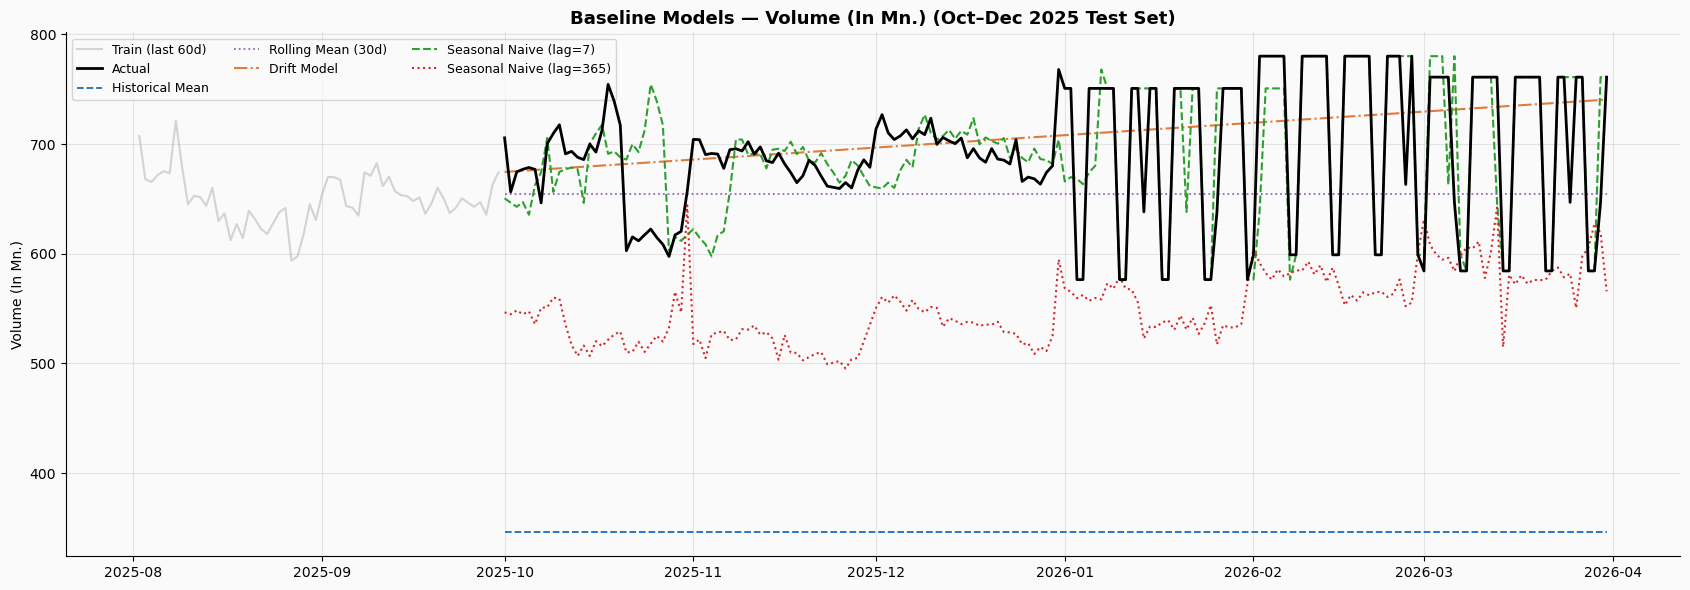

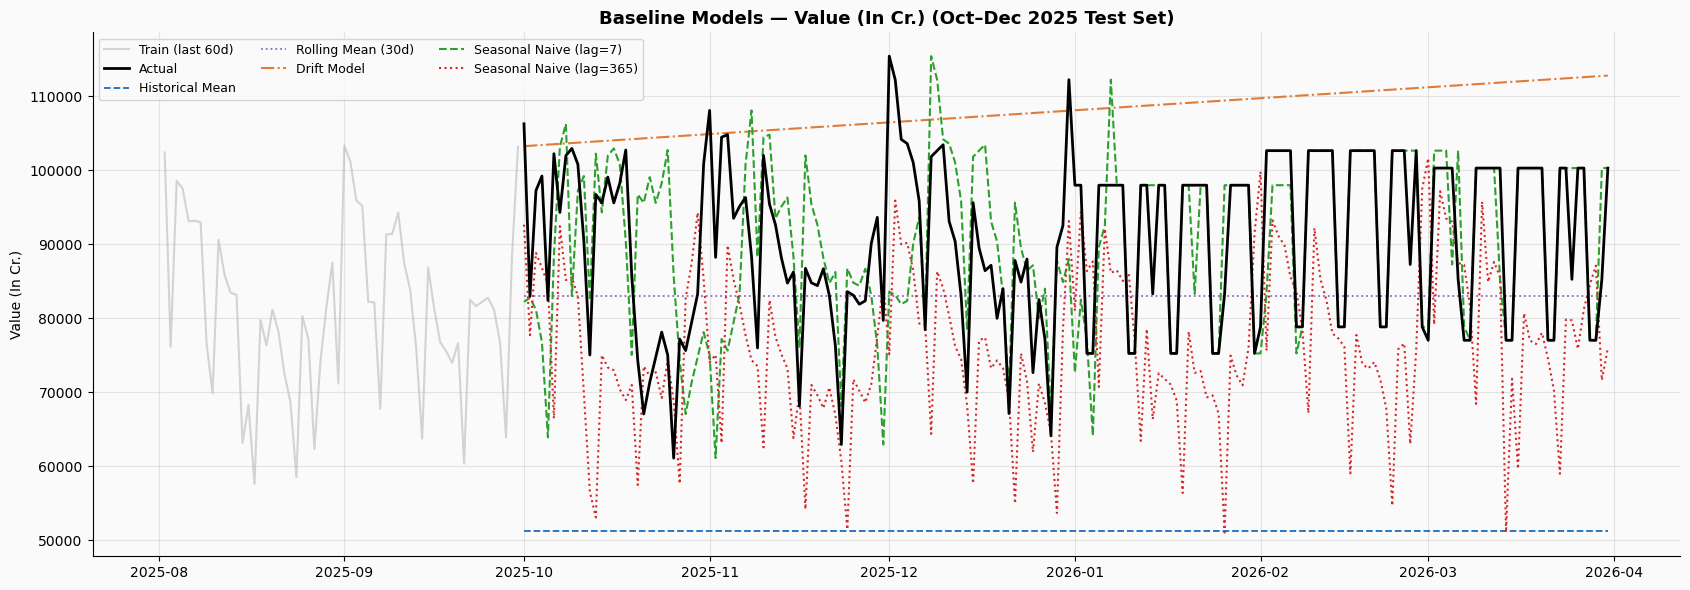

In [8]:
for TARGET in ["Volume (In Mn.)", "Value (In Cr.)"]:
    full_series = df.set_index("Date")[TARGET]
    actual      = test[TARGET].values
    test_dates  = pd.to_datetime(test["Date"].values)
    train_vals  = train[TARGET].values

    # Recompute each forecast
    hist_mean   = np.full(len(actual), train_vals.mean())
    last30_mean = np.full(len(actual), train_vals[-30:].mean())

    slope       = (train_vals[-1] - train_vals[0]) / (len(train_vals) - 1)
    drift_preds = np.array([train_vals[-1] + slope*(i+1) for i in range(len(actual))])

    sn7 = np.array([
        full_series.get(d - pd.Timedelta(days=7), np.nan) for d in test_dates])
    sn365 = np.array([
        full_series.get(d - pd.Timedelta(days=365), np.nan) for d in test_dates])

    # Plot
    fig, ax = plt.subplots(figsize=(17, 6))

    # Train tail
    ax.plot(train["Date"].values[-60:], train_vals[-60:],
            color="lightgray", lw=1.5, label="Train (last 60d)", zorder=1)

    # Actual
    ax.plot(test_dates, actual, color="black", lw=2.0, label="Actual", zorder=10)

    # Baselines
    ax.plot(test_dates, hist_mean,   color=BLUE,   lw=1.3, linestyle="--",  label="Historical Mean")
    ax.plot(test_dates, last30_mean, color=PURPLE, lw=1.3, linestyle=":",   label="Rolling Mean (30d)")
    ax.plot(test_dates, drift_preds, color=ORANGE, lw=1.5, linestyle="-.",  label="Drift Model")
    ax.plot(test_dates, sn7,         color=GREEN,  lw=1.5, linestyle="--",  label="Seasonal Naive (lag=7)")
    ax.plot(test_dates, sn365,       color=RED,    lw=1.5, linestyle=":",   label="Seasonal Naive (lag=365)")

    ax.set_title(f"Baseline Models — {TARGET} (Oct–Dec 2025 Test Set)",
                 fontsize=13, fontweight="bold")
    ax.set_ylabel(TARGET)
    ax.legend(ncol=3, fontsize=9, loc="upper left")
    plt.tight_layout()
    tag = TARGET[:3].lower()
    plt.savefig(f"plots/02b_baselines_{tag}.png", dpi=150, bbox_inches="tight")
    plt.show()


## 8. Metrics Comparison Table
> Rank all baselines by MAPE. Also shows how much better/worse each is relative to the Seasonal Naive (lag=7) benchmark.

In [9]:
import pandas as pd

for TARGET in ["Volume (In Mn.)", "Value (In Cr.)"]:
    rows = [v for k, v in results.items() if TARGET in k]
    df_res = pd.DataFrame(rows).sort_values("MAPE").reset_index(drop=True)
    df_res.index += 1

    # % improvement over Historical Mean (worst baseline)
    worst_mape = df_res["MAPE"].max()
    df_res["vs_HMean (MAPE%)"] = ((worst_mape - df_res["MAPE"]) / worst_mape * 100).round(1)

    print(f"\n{'='*65}")
    print(f"  BASELINE RANKING — {TARGET}")
    print(f"{'='*65}")
    print(df_res[["model","MAE","RMSE","MAPE","vs_HMean (MAPE%)"]].to_string())
    print()

    best = df_res.iloc[0]
    print(f"  ★ Best baseline: {best['model']}  |  MAPE = {best['MAPE']:.2f}%")
    print(f"  → Any model in notebooks 3–6 must beat {best['MAPE']:.2f}% MAPE to be worth using.")



  BASELINE RANKING — Volume (In Mn.)
                      model       MAE      RMSE     MAPE  vs_HMean (MAPE%)
1    Seasonal Naive (lag=7)   25.8366   43.9783   3.8047              92.8
2               Drift Model   47.1653   63.6116   7.2569              86.3
3        Rolling Mean (30d)   63.8625   73.7847   9.0203              83.0
4  Seasonal Naive (lag=365)  144.6540  157.5632  20.2574              61.7
5           Historical Mean  347.6748  353.2669  49.7062               6.1
6         Historical Median  370.0118  375.2712  52.9547               0.0

  ★ Best baseline: Seasonal Naive (lag=7)  |  MAPE = 3.80%
  → Any model in notebooks 3–6 must beat 3.80% MAPE to be worth using.

  BASELINE RANKING — Value (In Cr.)
                      model         MAE        RMSE     MAPE  vs_HMean (MAPE%)
1    Seasonal Naive (lag=7)   7303.0457  11247.0497   8.2060              81.6
2        Rolling Mean (30d)  11828.9300  13803.6445  12.6291              71.7
3  Seasonal Naive (lag=365)  167

## 9. Error Distribution Plot
> Box plots showing how spread out each baseline's errors are.

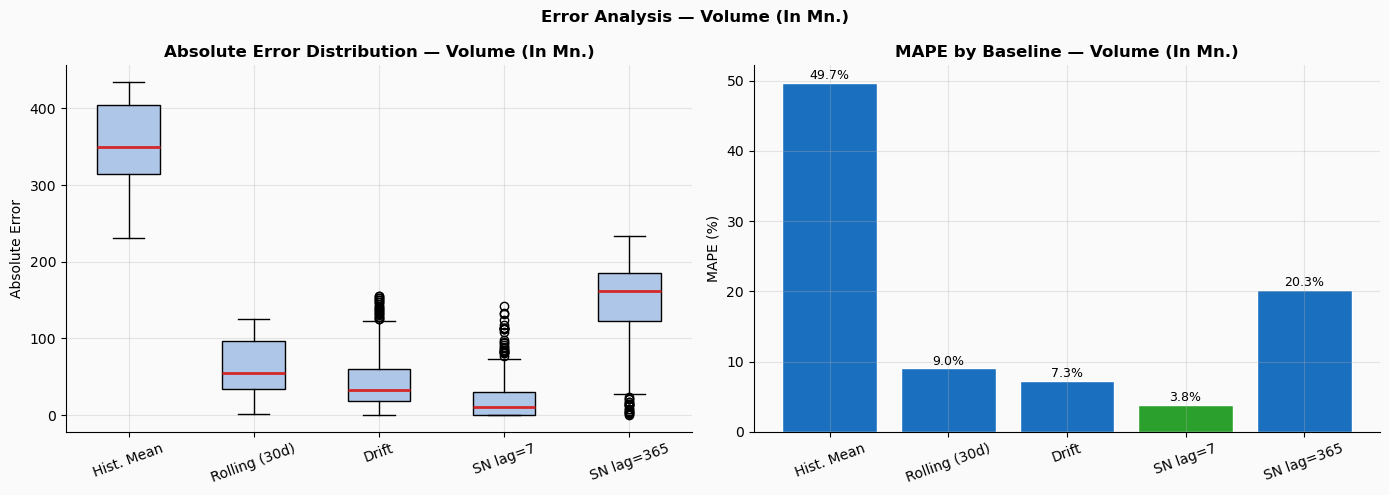

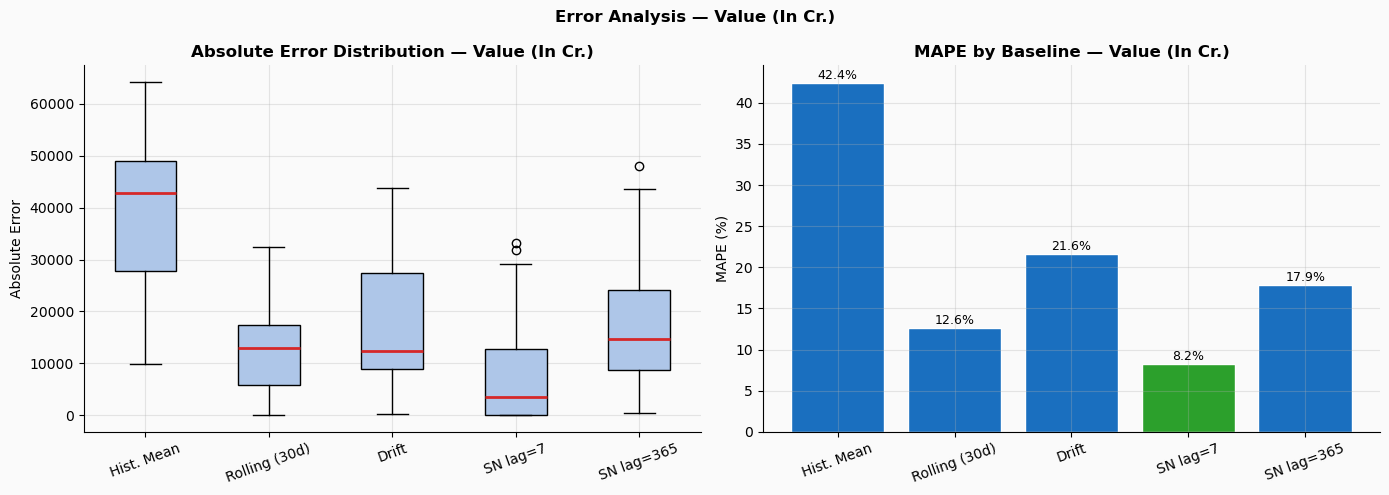

In [10]:
for TARGET in ["Volume (In Mn.)", "Value (In Cr.)"]:
    full_series = df.set_index("Date")[TARGET]
    actual      = test[TARGET].values
    test_dates  = pd.to_datetime(test["Date"].values)
    train_vals  = train[TARGET].values

    hist_mean   = np.full(len(actual), train_vals.mean())
    last30_mean = np.full(len(actual), train_vals[-30:].mean())
    slope       = (train_vals[-1] - train_vals[0]) / (len(train_vals) - 1)
    drift_preds = np.array([train_vals[-1] + slope*(i+1) for i in range(len(actual))])
    sn7  = np.array([full_series.get(d-pd.Timedelta(days=7),  np.nan) for d in test_dates])
    sn365= np.array([full_series.get(d-pd.Timedelta(days=365),np.nan) for d in test_dates])

    model_preds = {
        "Hist. Mean":    hist_mean,
        "Rolling (30d)": last30_mean,
        "Drift":         drift_preds,
        "SN lag=7":      sn7,
        "SN lag=365":    sn365,
    }
    error_data = {}
    for name, preds in model_preds.items():
        mask = ~np.isnan(preds)
        error_data[name] = np.abs(actual[mask] - preds[mask])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Absolute error box plot
    axes[0].boxplot(list(error_data.values()), labels=list(error_data.keys()),
                    patch_artist=True,
                    boxprops=dict(facecolor="#AEC6E8"),
                    medianprops=dict(color=RED, lw=2))
    axes[0].set_title(f"Absolute Error Distribution — {TARGET}", fontweight="bold")
    axes[0].set_ylabel("Absolute Error")
    axes[0].tick_params(axis="x", rotation=20)

    # MAPE per model bar
    mapes = {name: np.mean(err / actual[:len(err)]) * 100
             for name, err in error_data.items()}
    colors_ = [GREEN if v == min(mapes.values()) else BLUE for v in mapes.values()]
    bars = axes[1].bar(mapes.keys(), mapes.values(), color=colors_, edgecolor="white")
    for bar, val in zip(bars, mapes.values()):
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                     f"{val:.1f}%", ha="center", va="bottom", fontsize=9)
    axes[1].set_title(f"MAPE by Baseline — {TARGET}", fontweight="bold")
    axes[1].set_ylabel("MAPE (%)")
    axes[1].tick_params(axis="x", rotation=20)

    plt.suptitle(f"Error Analysis — {TARGET}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"plots/02b_baseline_errors_{TARGET[:3].lower()}.png", dpi=150, bbox_inches="tight")
    plt.show()


## 10. Save Metrics for Notebook 7 (Model Comparison)

In [11]:
saved = []
for key, m in results.items():
    fname = f"models/baseline_{m['model'].lower().replace(' ','_').replace('=','').replace('(','').replace(')','').replace('/','_')}_{m['target'][:3].lower()}_metrics.json"
    with open(fname, "w") as f:
        json.dump(m, f, indent=2)
    saved.append(fname)

print(f"✅ Saved {len(saved)} baseline metric files to models/")
for s in saved:
    print(f"  {s}")
print("\nRun 07_model_comparison.ipynb to see all models ranked together.")


✅ Saved 12 baseline metric files to models/
  models/baseline_historical_mean_vol_metrics.json
  models/baseline_historical_median_vol_metrics.json
  models/baseline_historical_mean_val_metrics.json
  models/baseline_historical_median_val_metrics.json
  models/baseline_seasonal_naive_lag7_vol_metrics.json
  models/baseline_seasonal_naive_lag7_val_metrics.json
  models/baseline_seasonal_naive_lag365_vol_metrics.json
  models/baseline_seasonal_naive_lag365_val_metrics.json
  models/baseline_rolling_mean_30d_vol_metrics.json
  models/baseline_rolling_mean_30d_val_metrics.json
  models/baseline_drift_model_vol_metrics.json
  models/baseline_drift_model_val_metrics.json

Run 07_model_comparison.ipynb to see all models ranked together.


## Summary

| Baseline | Complexity | Captures Trend | Captures Weekly Cycle | Expected MAPE |
|---|---|---|---|---|
| Historical Mean | Trivial | ❌ | ❌ | Very High |
| Historical Median | Trivial | ❌ | ❌ | Very High |
| Rolling Mean (30d) | Trivial | Partially | ❌ | High |
| Drift Model | Low | ✅ | ❌ | Moderate |
| Seasonal Naive (lag=7) | Low | ❌ | ✅ | Moderate |
| Seasonal Naive (lag=365) | Low | Partially | Partially | Moderate–Low |

**Key takeaway:** If SARIMA/Prophet/LSTM can't beat the Seasonal Naive (lag=7), there's something wrong with the model. These baselines set the minimum bar.
